#  Calculation of features from available libraries

In [1]:
import sys
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')

import os
import pandas as pd

dataset = 'Fe-Mo'
system=dataset.replace('-','')
from BopFoxFeaturizer.Featurizer import Featurizer

BS = pd.read_pickle(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.pkl'))
AtomsObjects = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')).dropna()
SublatticeTags = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SUBLATICETAGS.pkl'))
SublatticeSorters = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SORTERS.pkl'))
SublatticeSorters.index = SublatticeSorters.index.str.strip()
SublatticeTags.index = SublatticeSorters.index.str.strip()
BS.dropna(inplace=True)

In [2]:
import matplotlib.pyplot as plt
plt.rc('font', size=22)
plt.rc('figure', figsize=(12,8))

## Prepare Extra features

In [3]:
Features = Featurizer(BS)

In [4]:
DatasetCompositionFeatures = Features.get_fractions_by_components()

In [5]:
Features.__dict__.keys()

dict_keys(['data', 'atom_volume_list', 'df_struc', 'Sym', 'Struc', 'StrucNames', 'Mag', 'occupation', 'structures_tcp', 'crystal_not_tcp', 'list_not_tcp', 'dic_structures', 'all_atom_occ', 'all_atom_occ_reverse', 'components', 'MagFeature', 'multiply_cutoff'])

In [6]:
DatasetMagneticFeature = Features.Mag
#DatasetMagneticFeature = DatasetMagneticFeature.str.replace('FM','1.')
#DatasetMagneticFeature = DatasetMagneticFeature.str.replace('NM','0.').astype(float)
DatasetMagneticFeature.name = 'Mag'

In [7]:
StructureNameFeature = BS.Phase

In [8]:
StructureNameFeature.name='Structure'

In [9]:
DatasetFeatures = pd.concat((DatasetCompositionFeatures, DatasetMagneticFeature, StructureNameFeature), axis=1)

In [10]:
from sklearn.preprocessing import  OneHotEncoder, LabelEncoder

In [11]:
encoder = LabelEncoder()# OneHotEncoder()

In [12]:
encoder.fit(DatasetFeatures['Structure']) #, 'Mag']])

LabelEncoder()

In [13]:
transformed_structure = pd.DataFrame(encoder.transform(DatasetFeatures['Structure']), columns=['Structure'], index=DatasetFeatures.index)  #, 'Mag']])

In [14]:
encoder.fit(DatasetFeatures['Mag'])

LabelEncoder()

In [15]:
transformed_mag = pd.DataFrame(encoder.transform(DatasetFeatures['Mag']), columns=['Mag'], index=DatasetFeatures.index)

In [16]:
#dftransformed = pd.DataFrame(transformed_mag.toarray(), columns = encoder.get_feature_names_out(), index = DatasetFeatures.index)

In [17]:
DatasetFeatures.drop(columns = ['Mag', 'Structure'],  inplace=True)

In [18]:
DatasetFeatures = pd.concat([DatasetFeatures, transformed_mag, transformed_structure], axis = 1) #dftransformed], axis = 1)

In [19]:
datasetfeatureslocation = os.path.join(dataset, 'Descriptors','DatasetFeatures.pkl')

In [20]:
descriptorslocation = os.path.join(dataset, 'Descriptors')

# Coordination polyhedra feature

In [21]:
import Tools.DatasetTools.GeneralFeaturizer as gf

In [22]:
SortingFeatures = gf.sorting_feature(AtomsObjects, SublatticeSorters, SublatticeTags)

In [23]:
SortingFeatures.sorters = gf.correct_sortings_fromphases(AtomsObjects, BS.Phase, SortingFeatures.sorters)

In [24]:
SortingFeatures.sublatticetags = gf.correct_occupation_fromphases(Features.occupation, BS.Phase, SortingFeatures.sublatticetags)

In [25]:
SortingFeatures.sublatticetags

Fe_pv8Mo_sv22.sigma-BBABB.FM     [A, A, B, B, B, B, C, C, C, C, C, C, C, C, D, ...
Fe_pv10Mo_sv20.sigma-ABBAB.FM    [A, A, B, B, B, B, C, C, C, C, C, C, C, C, D, ...
Fe_pv4Mo_sv20.C36-ABBBB.FM       [A, A, A, A, B, B, B, B, C, C, C, C, D, D, D, ...
Fe_pv3Mo_sv10.mu-ABBBA.FM                  [A, B, B, B, B, B, B, C, C, D, D, E, E]
Fe_pv5Mo_sv24.chi-AABB.FM        [A, B, B, B, B, C, C, C, C, C, C, C, C, C, C, ...
                                                       ...                        
Fe_pv3Mo_sv10.mu-ABBBA.NM                  [A, B, B, B, B, B, B, C, C, D, D, E, E]
Fe_pv8Mo_sv22.sigma-BBABB.NM     [A, A, B, B, B, B, C, C, C, C, C, C, C, C, D, ...
Fe_pv1Mo_sv3.L12-AB3.FM                                                   [, , , ]
Fe_pv8Mo_sv22.sigma-BBBBA.FM     [A, A, B, B, B, B, C, C, C, C, C, C, C, C, D, ...
Fe_pv10Mo_sv20.sigma-ABBAB.NM    [A, A, B, B, B, B, C, C, C, C, C, C, C, C, D, ...
Name: sublatticetags, Length: 289, dtype: object

In [26]:
sampleinspecial = BS.Phase.map(lambda p: p in gf.specialphases)

In [27]:
empty = SortingFeatures.sublatticetags.map(lambda sublat: '' in sublat)

In [28]:
SortingFeatures.sublatticetags[empty] = ['A']

In [29]:
wrong = SortingFeatures.sublatticetags.map(lambda sublat: 'A' not in sublat) 

In [30]:
import numpy as np

In [31]:
uniquewrong = SortingFeatures.sublatticetags[wrong].map(np.unique)

In [32]:
latticetags = list('ABCDEFGHIJK')

In [33]:
latticetags

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']

In [34]:
CNList = gf.get_sitecn(BS.Phase, AtomsObjects.atoms, SortingFeatures.sorters)

  0%|          | 0/289 [00:00<?, ?it/s]

# Position Features 

In [35]:
ABOCC = pd.concat([BS.filter(regex='atom_'), Features.occupation], axis = 1)

In [36]:
Positions = {}
for index, item in ABOCC.iterrows():
    if item['index'] == '':
        thisposition = {index: [item[f'atom_A']]*len(np.unique(gf.cn_dict[BS.Phase[index]]))}
    else:
        thisposition = {index: [item[f'atom_{occ}'] for occ in item['index'] ]}
    Positions.update(thisposition)

In [37]:
Positions = pd.DataFrame.from_dict(Positions, orient='index')

In [38]:
Positions[Positions.isnull()] = 0

In [39]:
Positions[Positions=='Mo_sv'] = 2

In [40]:
Positions[Positions=='Fe_pv'] = 1

In [41]:
Positions.columns = [f'Pos_{col+1}' for col in Positions.columns]

In [42]:
Positions[Positions.Pos_1.map(type) == str] = np.nan

# Pyscal features 

In [43]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [44]:
from tqdm.auto import tqdm
from Tools.DatasetTools import pyscalfeaturizers as pf
from BopFoxFeaturizer.struct_db import struct_db
AtomsObjects = pd.read_pickle(atomsobjectfile).dropna()

In [45]:
featurizers = [pf.pyscal_steinhardt, pf.pyscal_cn] #, get_steinhardt]
pyscal_features = [feature.__name__ for feature in featurizers]

pyscalsteinhardt = os.path.join(descriptorslocation, 'pyscal_steinhardt.kpl')

if os.path.exists(pyscalsteinhardt):
    PyscalFeatures = pd.read_pickle(pyscalsteinhardt)
else:
    PyscalFeatures = pf.featurize_many(AtomsObjects,  featurizers, colid='atoms')
    expanded_ste = pf.expand_features(PyscalFeatures.pyscal_steinhardt, 'pyscal_steinhardt')
    PyscalFeatures = pd.concat([expanded_ste, PyscalFeatures.pyscal_cn], axis=1)
    PyscalFeatures.to_pickle(pyscalsteinhardt)

In [46]:
PyscalFeatures[BS.Phase == 'R'].pyscal_cn[0]

array([12, 12, 12, 12, 12, 12, 12, 12, 12, 11, 11, 12, 11, 11, 12, 12, 12,
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 12, 12, 13, 12, 12, 12,
       12, 12, 12, 12, 12, 15, 15, 15, 15, 15, 15, 16, 16, 15, 15, 15, 15,
       15, 15])

In [47]:
CNList[BS.Phase == 'R'][0]

array([12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16,
       16, 16])

In [48]:
PyscalFeatures.pyscal_cn

Fe_pv8Mo_sv22.sigma-BBABB.FM     [14, 14, 14, 14, 14, 14, 14, 14, 12, 12, 15, 1...
Fe_pv10Mo_sv20.sigma-ABBAB.FM    [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 15, 1...
Fe_pv4Mo_sv20.C36-ABBBB.FM       [16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 1...
Fe_pv3Mo_sv10.mu-ABBBA.FM        [12, 14, 14, 12, 12, 12, 12, 12, 12, 15, 15, 1...
Fe_pv5Mo_sv24.chi-AABB.FM        [16, 16, 16, 16, 16, 13, 13, 13, 13, 13, 13, 1...
                                                       ...                        
Fe_pv3Mo_sv10.mu-ABBBA.NM        [12, 14, 14, 12, 12, 12, 12, 12, 12, 15, 15, 1...
Fe_pv8Mo_sv22.sigma-BBABB.NM     [14, 14, 14, 14, 14, 14, 14, 14, 12, 12, 15, 1...
Fe_pv1Mo_sv3.L12-AB3.FM                                           [12, 12, 12, 12]
Fe_pv8Mo_sv22.sigma-BBBBA.FM     [14, 14, 14, 14, 14, 14, 14, 14, 12, 12, 15, 1...
Fe_pv10Mo_sv20.sigma-ABBAB.NM    [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 15, 1...
Name: pyscal_cn, Length: 289, dtype: object

# Dataset features from CN 

The first feature that we would like to have is the count of each CP in each sample. for that we construct a vector in the following way:

$$ N_{CN}^i = \#^i CN $$

## amount of sites in structure

In [49]:
import Tools.DatasetTools.GeneralFeaturizer as gf

In [50]:
from importlib.machinery import SourceFileLoader
gf = SourceFileLoader('gf','Tools/DatasetTools/GeneralFeaturizer.py').load_module()

In [51]:
CN = gf.featurize_series(CNList, CNList, normalization='NCP', return0 = False)
newcolumns = ['N'+col for col in CN.columns]
CN.columns = newcolumns

In [52]:
CN

,N_CN12,N_CN13,N_CN14,N_CN15,N_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,12.0,0.0,14.0,15.0,0.0
Fe_pv10Mo_sv20.sigma-ABBAB.FM,12.0,0.0,14.0,15.0,0.0
Fe_pv4Mo_sv20.C36-ABBBB.FM,12.0,0.0,0.0,0.0,16.0
Fe_pv3Mo_sv10.mu-ABBBA.FM,12.0,0.0,14.0,15.0,16.0
Fe_pv5Mo_sv24.chi-AABB.FM,12.0,13.0,0.0,0.0,16.0
...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,12.0,0.0,14.0,15.0,16.0
Fe_pv8Mo_sv22.sigma-BBABB.NM,12.0,0.0,14.0,15.0,0.0
Fe_pv1Mo_sv3.L12-AB3.FM,12.0,0.0,0.0,0.0,0.0
Fe_pv8Mo_sv22.sigma-BBBBA.FM,12.0,0.0,14.0,15.0,0.0


## Composition on CP

Next feature we want is the composition in each CP. for this we choose to represent the elment numerically by their atomic numbers, and the CP-resolved composition becomes the average atomc numbers,

$$ Z_{CP} ^i = \dfrac{1}{n_{at}^i} \sum_{at \in CP} Z_{at} $$

In [53]:
from mendeleev import element

In [54]:
AtomicNumbers=AtomsObjects.atoms.map(lambda a: a.numbers)
AtomicNumbers.name = 'AtomicNumbers'

In [55]:
symbols = dataset.split('-')

In [56]:
volums = {symb: element(symb).atomic_volume for symb in symbols}

In [57]:
AtomicVolumes = AtomsObjects.atoms.map(lambda a: [volums[at] for at in a.get_chemical_symbols()])

In [58]:
AtomsObjects.drop(index='Mo_sv56.delta.NM', inplace=True)

In [59]:
CPVol = gf.featurize_series(AtomicVolumes, CNList, return0=False, normalization='NCP')
newcolumns = ['V'+col for col in CPVol.columns]
CPVol.columns =  newcolumns

In [60]:
CPComp = gf.featurize_series(AtomicNumbers, CNList, return0=False, normalization='NCP')
newcolumns = ['Z'+col for col in CPComp.columns]
CPComp.columns = newcolumns

# compare to alesya's descriptors - positions in decoration

In [61]:
previous = pd.read_csv('Fe-Mo/DATAforML_without_BOP.csv')

In [62]:
previous = previous.set_index('index1')

In [63]:
previous_features = previous.drop(columns=['Name','V', 'E0', 'E0', 'B0', 'EF','atom_A', 'atom_B','Order_AB'],)

In [64]:
interception = previous.index.intersection(DatasetFeatures.index)

In [65]:
interception

Index(['Fe_pv8Mo_sv22.sigma-BBABB.FM', 'Fe_pv10Mo_sv20.sigma-ABBAB.FM',
       'Fe_pv4Mo_sv20.C36-ABBBB.FM', 'Fe_pv3Mo_sv10.mu-ABBBA.FM',
       'Fe_pv5Mo_sv24.chi-AABB.FM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv6Mo_sv18.C36-BBBBA.NM', 'Fe_pv6Mo_sv18.C36-BBBBA.FM',
       'Fe_pv2Mo_sv11.mu-BBABB.NM', 'Fe_pv2Mo_sv11.mu-BBBAB.NM',
       ...
       'Fe_pv4Mo_sv20.C36-BABBB.FM', 'Fe_pv4Mo_sv20.C36-BABBB.NM',
       'Fe_pv3Mo_sv10.mu-ABBAB.FM', 'Fe_pv5Mo_sv24.chi-AABB.NM',
       'Fe_pv6Mo_sv18.C36-BBBAB.NM', 'Fe_pv6Mo_sv18.C36-BBBAB.FM',
       'Fe_pv3Mo_sv10.mu-ABBBA.NM', 'Fe_pv8Mo_sv22.sigma-BBABB.NM',
       'Fe_pv8Mo_sv22.sigma-BBBBA.FM', 'Fe_pv10Mo_sv20.sigma-ABBAB.NM'],
      dtype='object', length=255)

In [66]:
#(DatasetFeatures.Mag.loc[interception] == previous.Magnetism.loc[interception]).sum()

In [67]:
index_delta = Positions.index[Positions.index.str.contains('delta')]

In [68]:
Positions.drop(index = index_delta, inplace=True)

<AxesSubplot:>

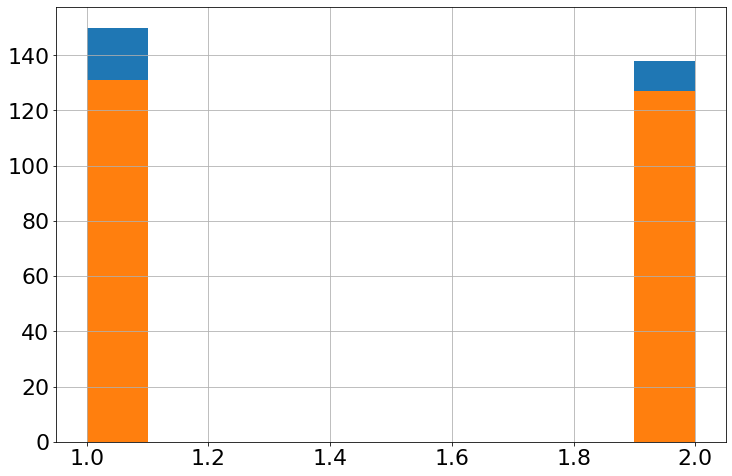

In [69]:
ax = Positions.Pos_1.hist()
previous.Pos_1.hist(ax = ax)

<AxesSubplot:>

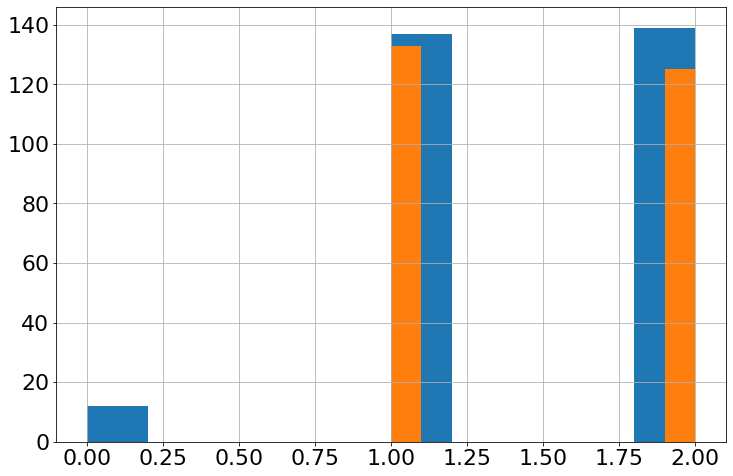

In [70]:
ax = Positions.Pos_2.hist()
previous.Pos_2.hist(ax = ax)

In [71]:
zero_pos2_index = Positions.Pos_2[Positions.Pos_2 == 0]

In [72]:
zero_pos2_index

Mo_sv2.hcp.FM          0
Mo_sv2.hcp.NM          0
Mo_sv4.fcc-cubic.NM    0
Mo_sv4.fcc-cubic.FM    0
Mo_sv1.bcc.FM          0
Mo_sv1.bcc.NM          0
Fe_pv1.bcc.NM          0
Fe_pv2.hcp.FM          0
Fe_pv4.fcc-cubic.NM    0
Fe_pv4.fcc-cubic.FM    0
Fe_pv2.hcp.NM          0
Fe_pv1.bcc.FM          0
Name: Pos_2, dtype: object

In [73]:
zero_pos2_index.index.intersection(previous.index)

Index([], dtype='object')

then I have differences because I have more samples 

# Final Dataset Features

In [74]:
DatasetFeatures = pd.concat([DatasetFeatures, CPComp, CPVol,CN, Positions, BS.num_atoms], axis=1)

In [75]:
DatasetCompositionFeatures.drop(columns=['Mo_sv'], inplace=True)

# pairplots 

In [76]:
import seaborn as sns

In [77]:
def merge_to_compare(mine, previous):
    toplot_mine = mine.copy()
    toplot_mine['dataset'] = 'mine'
    toplot_prevous = previous.filter(regex='Z')
    toplot_prevous.columns = mine.columns
    toplot_prevous['dataset'] = 'previous'
    return pd.concat([toplot_mine, toplot_prevous], axis=0).reset_index()

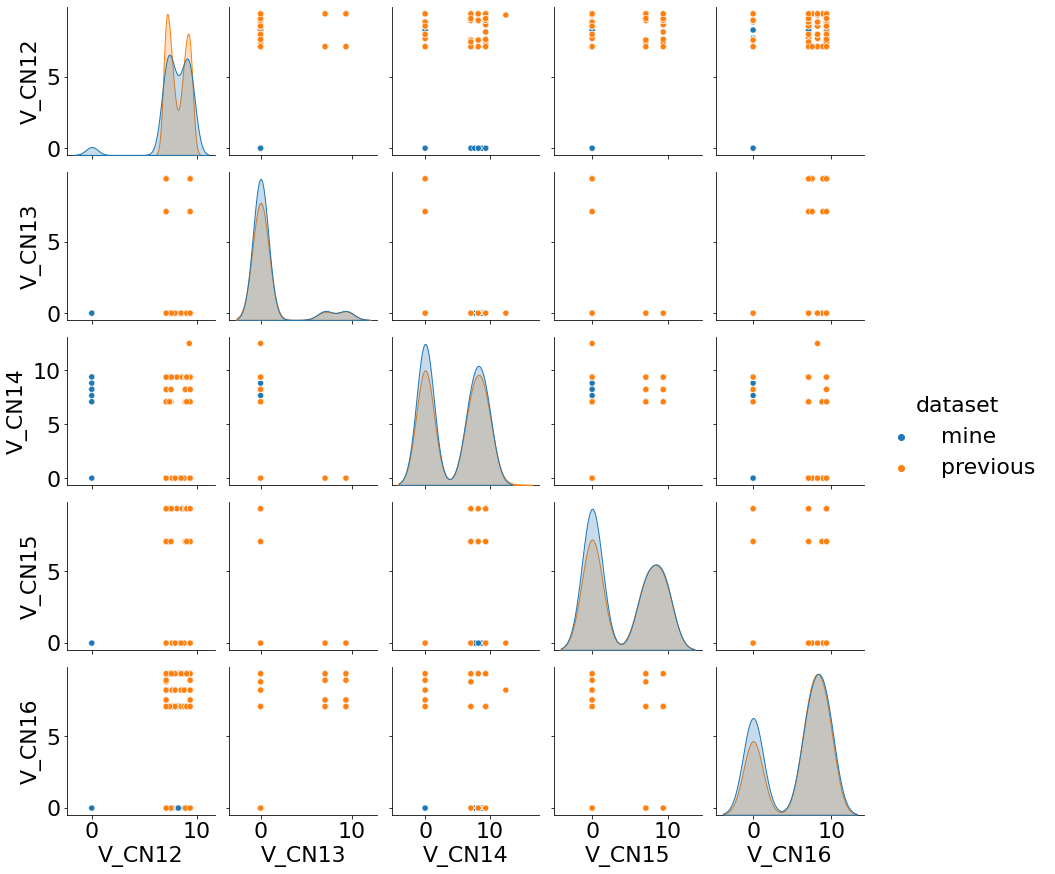

In [78]:
grid = sns.pairplot(merge_to_compare(CPVol, previous.filter(regex='Z')), hue='dataset')

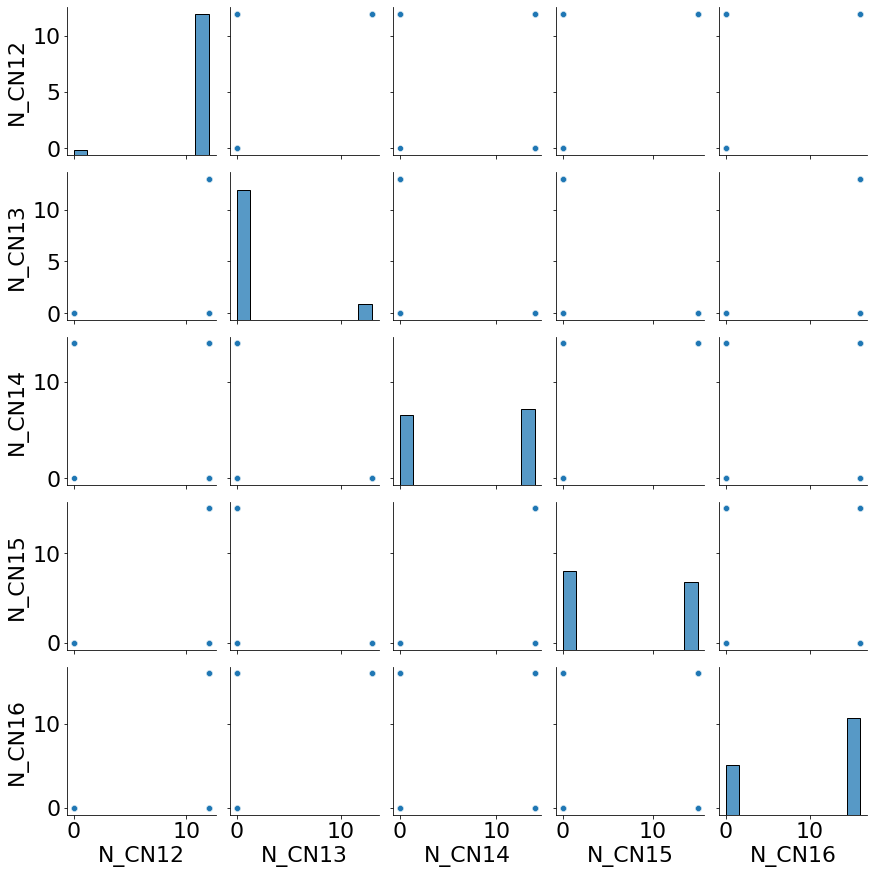

In [79]:
sns.pairplot(CN)

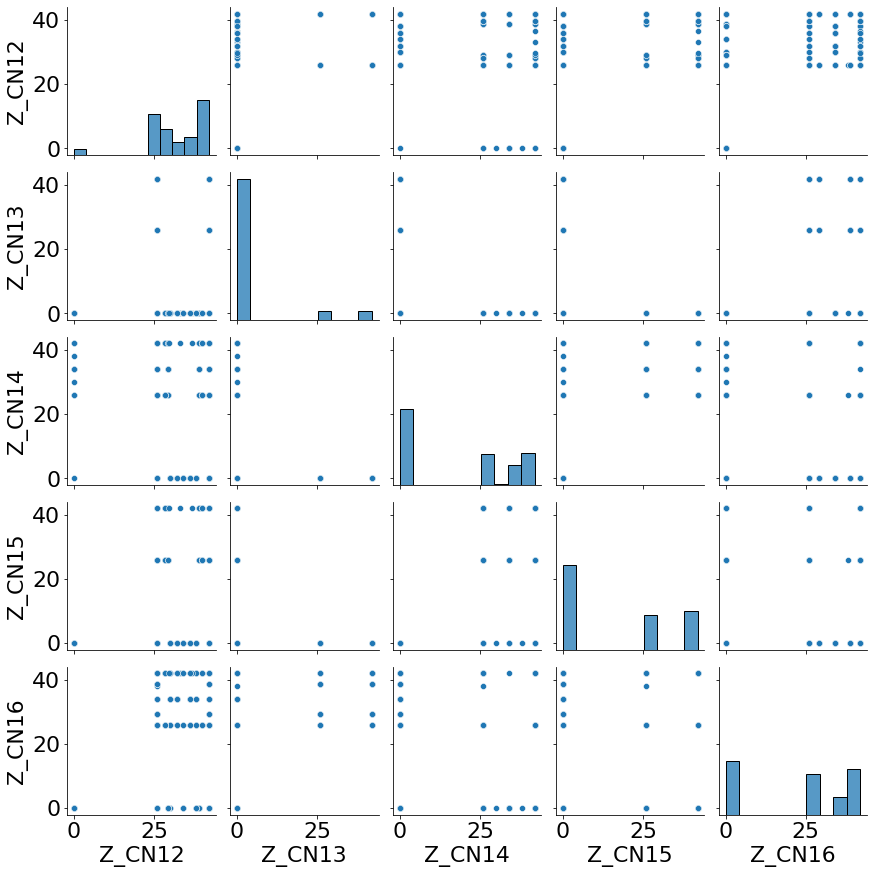

In [80]:
sns.pairplot(CPComp)

# Compare volume features

In [81]:
VolumesC14 = AtomicVolumes[AtomicVolumes.index.str.contains('C14')]

In [82]:
VolumesC14

index
Fe_pv2Mo_sv10.C14-BAB.NM    [7.1, 7.1, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, ...
Fe_pv2Mo_sv10.C14-BAB.FM    [7.1, 7.1, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, ...
Mo_sv12.C14.FM              [9.4, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, ...
Mo_sv12.C14.NM              [9.4, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, ...
Fe_pv12.C14.NM              [7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, ...
Fe_pv12.C14.FM              [7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, ...
Fe_pv10Mo_sv2.C14-ABA.NM    [7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, ...
Fe_pv10Mo_sv2.C14-ABA.FM    [7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, ...
Fe_pv6Mo_sv6.C14-AAB.NM     [7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 9.4, 9.4, 9.4, ...
Fe_pv6Mo_sv6.C14-AAB.FM     [7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 9.4, 9.4, 9.4, ...
Fe_pv8Mo_sv4.C14-BAA.NM     [7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 9.4, ...
Fe_pv8Mo_sv4.C14-BAA.FM     [7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 7.1, 9.4, ...
Fe_pv4Mo_sv8.C14-ABB.FM     [7.1, 7.1, 7.1, 7.1, 9.4, 9.4,

In [83]:
VolumesC14[0]

[7.1, 7.1, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4, 9.4]

In [84]:
sample = VolumesC14.index[0]

In [85]:
sample

'Fe_pv2Mo_sv10.C14-BAB.NM'

In [86]:
CPVol.loc[sample]

V_CN12    8.825
V_CN13    0.000
V_CN14    0.000
V_CN15    0.000
V_CN16    9.400
Name: Fe_pv2Mo_sv10.C14-BAB.NM, dtype: float64

In [87]:
AtomsObjects['atoms'][sample].get_chemical_symbols()

['Fe', 'Fe', 'Mo', 'Mo', 'Mo', 'Mo', 'Mo', 'Mo', 'Mo', 'Mo', 'Mo', 'Mo']

In [88]:
CN.loc[sample]

N_CN12    12.0
N_CN13     0.0
N_CN14     0.0
N_CN15     0.0
N_CN16    16.0
Name: Fe_pv2Mo_sv10.C14-BAB.NM, dtype: float64

In [89]:
previous_features.filter(regex='Z').loc[sample]

Z12    8.8075
Z13    0.0000
Z14    0.0000
Z15    0.0000
Z16    9.3800
Name: Fe_pv2Mo_sv10.C14-BAB.NM, dtype: float64

In [90]:
CPVol.loc[sample]

V_CN12    8.825
V_CN13    0.000
V_CN14    0.000
V_CN15    0.000
V_CN16    9.400
Name: Fe_pv2Mo_sv10.C14-BAB.NM, dtype: float64

In [91]:
previous.loc[sample]

Name                                    bulk  C14-BAB
V                                           15.321325
E0                                          -10.20805
nelem                                               2
atom_A                                          Fe_pv
atom_B                                          Mo_sv
num_atom_A                                          2
num_atom_B                                         10
num_atoms                                        12.0
EF                                           0.279735
B0                                         244.837741
Magnetism                                         0.0
Structure_number                                    1
fraction_Fe                                  0.333333
Order_AB            [2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0]
Pos_1                                               2
Pos_2                                               1
Pos_3                                               2
Pos_4                       

In [92]:
BS.loc[sample]

                           bulk  C14-BAB
V                           15.321325 A 
E0                             -10.20805
B                        244.837741 GPa 
fit           murnaghan  volume_relaxed 
xc                               PBE-PAW
encut                                450
deltak                             0.020
ncrash                                 0
nelem                                  2
B0                            244.837741
V0                             15.321325
atom_A                             Fe_pv
atom_B                             Mo_sv
atom_C                                  
num_atom_A                             2
num_atom_B                            10
num_atom_C                             0
num_atoms                           12.0
Fe_pv                           0.166667
Mo_sv                           0.833333
EF                              0.279735
Phase                                C14
Name: Fe_pv2Mo_sv10.C14-BAB.NM, dtype: object

#  from table of sites by structure

In [93]:
(2*volums['Fe']+6*volums['Mo'])/8

8.825000000000001

In [94]:
volums['Mo']

9.4

In [95]:
volums['Fe']

7.1

In [96]:
sample

'Fe_pv2Mo_sv10.C14-BAB.NM'

In [97]:
PyscalFeatures.pyscal_cn[sample]

array([12, 12, 16, 16, 16, 16, 12, 12, 12, 12, 12, 12])

In [98]:
AtomsObjects.file[sample]

array(['Fe-Mo/Fe_pv-Mo_sv/POSCAR-initial/C14-BAB/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.initial'],
      dtype=object)

In [99]:
DatasetFeatures

,Fe_pv,Mo_sv,Mag,Structure,Z_CN12,Z_CN13,Z_CN14,Z_CN15,Z_CN16,V_CN12,...,Pos_3,Pos_4,Pos_5,Pos_6,Pos_7,Pos_8,Pos_9,Pos_10,Pos_11,num_atoms
Fe_pv8Mo_sv22.sigma-BBABB.FM,0.266667,0.733333,0,11,42.000000,0.0,34.0,42.0,0.0,9.400000,...,1,2,2,0,0,0,0,0,0,30.0
Fe_pv10Mo_sv20.sigma-ABBAB.FM,0.333333,0.666667,0,11,26.000000,0.0,42.0,42.0,0.0,7.100000,...,2,1,2,0,0,0,0,0,0,30.0
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.166667,0.833333,0,3,42.000000,0.0,0.0,0.0,34.0,9.400000,...,2,2,2,0,0,0,0,0,0,24.0
Fe_pv3Mo_sv10.mu-ABBBA.FM,0.230769,0.769231,0,10,39.714286,0.0,26.0,42.0,42.0,9.071429,...,2,2,1,0,0,0,0,0,0,13.0
Fe_pv5Mo_sv24.chi-AABB.FM,0.172414,0.827586,0,6,42.000000,42.0,0.0,0.0,26.0,9.400000,...,2,2,0,0,0,0,0,0,0,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,0.230769,0.769231,1,10,39.714286,0.0,26.0,42.0,42.0,9.071429,...,2,2,1,0,0,0,0,0,0,13.0
Fe_pv8Mo_sv22.sigma-BBABB.NM,0.266667,0.733333,1,11,42.000000,0.0,34.0,42.0,0.0,9.400000,...,1,2,2,0,0,0,0,0,0,30.0
Fe_pv1Mo_sv3.L12-AB3.FM,0.250000,0.750000,0,8,38.000000,0.0,0.0,0.0,0.0,8.825000,...,2,1,0,0,0,0,0,0,0,4.0
Fe_pv8Mo_sv22.sigma-BBBBA.FM,0.266667,0.733333,0,11,42.000000,0.0,34.0,42.0,0.0,9.400000,...,2,2,1,0,0,0,0,0,0,30.0


# some machine learning 

In [100]:
sns.set(rc={"figure.figsize":(12, 8)})

In [101]:
import numpy as np

In [102]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error

In [103]:
def inspectfeatures(thefeatures):
    interception = thefeatures.index.intersection(BS['EF'].index)
    xtrain, xtest, ytrain, ytest = train_test_split(thefeatures.loc[interception], BS.loc[interception]['EF'])
    paramsgrid = {'max_depth':np.arange(1, 20)}
    model = DecisionTreeRegressor(random_state=42)
    gridsearch = GridSearchCV(model, paramsgrid, scoring='neg_root_mean_squared_error', verbose=1, return_train_score=True)
    gridsearch.fit(xtrain, ytrain)
    results = pd.DataFrame(gridsearch.cv_results_)
    results['max_depth'] = results.params.map(lambda p: list(p.values())[0])
    return results, gridsearch

In [104]:
def plot_test_train(theresults, case='', ax = None, fig=None):
    if ax == None:
        fig, ax = plt.subplots()
    sns.scatterplot(theresults.max_depth, -theresults['mean_train_score'], ci='std_train_score', ax = ax, label=case+' train')
    sns.scatterplot(theresults.max_depth, -theresults['mean_test_score'], ci='std_test_score', ax = ax, label=case+' test')
    return ax

In [105]:
intercept = DatasetFeatures.index.intersection(previous.index)

In [121]:
%store intercept

Stored 'intercept' (Index)


In [106]:
result_previous, gridsearch_previous = inspectfeatures(previous_features)

Fitting 5 folds for each of 19 candidates, totalling 95 fits


In [107]:
DatasetFeatures.dropna(inplace=True)

In [108]:
results, gridsearch = inspectfeatures(DatasetFeatures.loc[intercept])

Fitting 5 folds for each of 19 candidates, totalling 95 fits


Text(0.5, 1.0, 'Fe-Mo system, prediction on $\\Delta E_f$, dataset features')

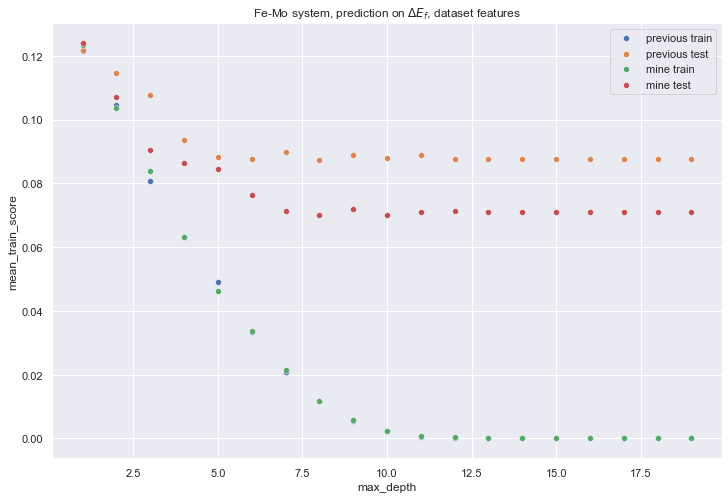

In [109]:
ax = plot_test_train(result_previous, case = 'previous')
ax = plot_test_train(results, ax = ax, case = 'mine')
ax.set_title(f'{dataset} system, prediction on $\Delta E_f$, dataset features')

In [110]:
def inspect_importances (thegridsearch):
    sorter = np.argsort(thegridsearch.best_estimator_.feature_importances_)
    sns.barplot(thegridsearch.best_estimator_.feature_importances_[sorter], thegridsearch.best_estimator_.feature_names_in_[sorter], orient='horizontal')

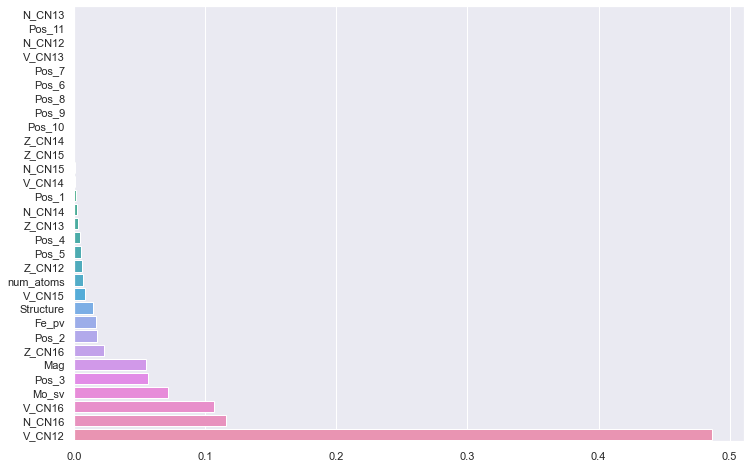

In [111]:
inspect_importances(gridsearch)

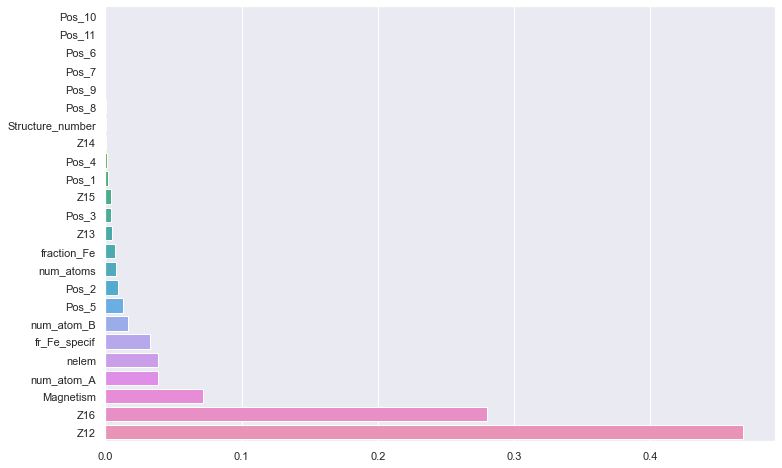

In [112]:
inspect_importances(gridsearch_previous)

# caveats 

the problem is that if I included the R samples then the test score gets a bit worse

In [113]:
results_full, gridsearch_full = inspectfeatures(DatasetFeatures)

Fitting 5 folds for each of 19 candidates, totalling 95 fits


Text(0.5, 1.0, 'Fe-Mo system, prediction on $\\Delta E_f$, dataset features')

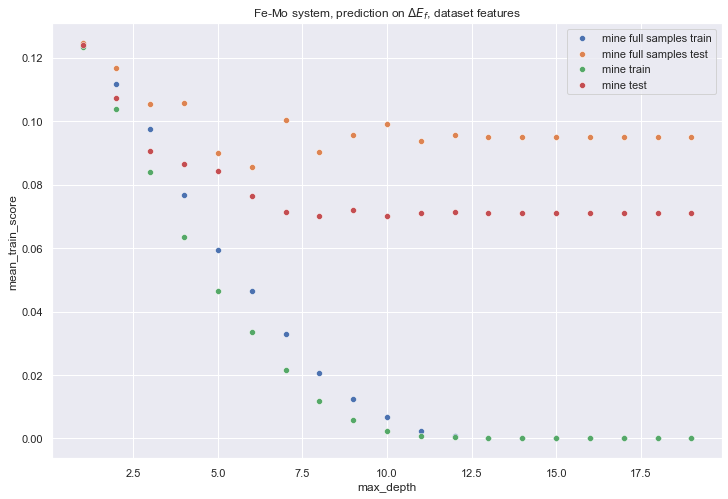

In [114]:
ax = plot_test_train(results_full, case = 'mine full samples')
ax = plot_test_train(results, ax = ax, case = 'mine')
ax.set_title(f'{dataset} system, prediction on $\Delta E_f$, dataset features')

In [115]:
gridsearch

GridSearchCV(estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])},
             return_train_score=True, scoring='neg_root_mean_squared_error',
             verbose=1)

In [116]:
difference = DatasetFeatures.index.difference(intercept)

In [117]:
intercept

Index(['Fe_pv8Mo_sv22.sigma-BBABB.FM', 'Fe_pv10Mo_sv20.sigma-ABBAB.FM',
       'Fe_pv4Mo_sv20.C36-ABBBB.FM', 'Fe_pv3Mo_sv10.mu-ABBBA.FM',
       'Fe_pv5Mo_sv24.chi-AABB.FM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv6Mo_sv18.C36-BBBBA.NM', 'Fe_pv6Mo_sv18.C36-BBBBA.FM',
       'Fe_pv2Mo_sv11.mu-BBABB.NM', 'Fe_pv2Mo_sv11.mu-BBBAB.FM',
       ...
       'Fe_pv4Mo_sv20.C36-BABBB.FM', 'Fe_pv4Mo_sv20.C36-BABBB.NM',
       'Fe_pv3Mo_sv10.mu-ABBAB.FM', 'Fe_pv5Mo_sv24.chi-AABB.NM',
       'Fe_pv6Mo_sv18.C36-BBBAB.NM', 'Fe_pv6Mo_sv18.C36-BBBAB.FM',
       'Fe_pv3Mo_sv10.mu-ABBBA.NM', 'Fe_pv8Mo_sv22.sigma-BBABB.NM',
       'Fe_pv8Mo_sv22.sigma-BBBBA.FM', 'Fe_pv10Mo_sv20.sigma-ABBAB.NM'],
      dtype='object', length=255)

In [118]:
intercept[intercept.str.contains('R')]

Index(['Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM', 'Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM',
       'Mo_sv53.R.NM', 'Fe_pv53.R.NM', 'Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM',
       'Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM', 'Fe_pv37Mo_sv14.R-AAAAAAAABBB.NM',
       'Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM', 'Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM',
       'Fe_pv21Mo_sv32.R-AAAAABBBBBB.NM'],
      dtype='object')

In [119]:
difference

Index(['Fe_pv1.bcc.FM', 'Fe_pv1.bcc.NM', 'Fe_pv10Mo_sv14.C36-ABBBA.FM',
       'Fe_pv11Mo_sv2.mu-AAABA.FM', 'Fe_pv11Mo_sv2.mu-AABAA.FM',
       'Fe_pv13Mo_sv16.chi-ABAB.FM', 'Fe_pv1Mo_sv1.B2-AB.FM',
       'Fe_pv1Mo_sv1.B2-AB.NM', 'Fe_pv1Mo_sv1.L10-NiAl-AB.NM',
       'Fe_pv1Mo_sv1.hcp-AB.FM', 'Fe_pv1Mo_sv1.hcp-AB.NM',
       'Fe_pv1Mo_sv3.D03-AB3.NM', 'Fe_pv1Mo_sv3.L12-AB3.FM',
       'Fe_pv1Mo_sv3.L12-AB3.NM', 'Fe_pv2.hcp.FM', 'Fe_pv2.hcp.NM',
       'Fe_pv2Mo_sv2.B32-AB.NM', 'Fe_pv2Mo_sv4.C15-AB2.FM',
       'Fe_pv2Mo_sv4.C15-AB2.NM', 'Fe_pv2Mo_sv6.D0_19-AB3.FM',
       'Fe_pv2Mo_sv6.D0_19-AB3.NM', 'Fe_pv3Mo_sv1.D03-A3B.NM',
       'Fe_pv3Mo_sv1.L12-A3B.FM', 'Fe_pv3Mo_sv1.L12-A3B.NM',
       'Fe_pv4.fcc-cubic.FM', 'Fe_pv4.fcc-cubic.NM',
       'Fe_pv6Mo_sv2.D0_19-A3B.NM', 'Mo_sv1.bcc.FM', 'Mo_sv1.bcc.NM',
       'Mo_sv2.hcp.FM', 'Mo_sv2.hcp.NM', 'Mo_sv4.fcc-cubic.FM',
       'Mo_sv4.fcc-cubic.NM'],
      dtype='object')

In [120]:
EFP = gridsearch.predict(DatasetFeatures.loc[difference])

In [ ]:
difference.interse